In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import scipy

In [3]:
df = pl.read_csv("pets.csv")

# remove classes with only one sample because I want to stratify the split later
useful_classes = df["class_id"].value_counts().filter(pl.col("count") > 1)["class_id"]
df = df.filter(pl.col("class_id").is_in(useful_classes.implode()))

class_counts = df["class_id"].value_counts()
print(f"Min samples per class: {class_counts['count'].min()}")
print(f"Max samples per class: {class_counts['count'].max()}")

num_classes = df["class_id"].n_unique()
num_samples = df.shape[0]
print(f"Number of classes: {num_classes}")
print(f"Total number of samples: {num_samples}")
df.head(5)

Min samples per class: 3
Max samples per class: 20
Number of classes: 38
Total number of samples: 362


class_id,class_name,filename
i64,str,str
0,""" simba""",""" simba/00000.jpg"""
0,""" simba""",""" simba/00001.jpg"""
0,""" simba""",""" simba/00002.jpg"""
0,""" simba""",""" simba/00003.jpg"""
0,""" simba""",""" simba/00004.jpg"""


In [4]:
# I will stratify between train and test_val because I feel bad training a model for classes that they wont see
# however there are classes that have only 3 samples so I wont stratify between test and val.
# Therefore all classes have one sample in at least test or val
train, test_val = sklearn.model_selection.train_test_split(df, test_size=0.2, random_state=42, stratify=df["class_id"])
test, val = sklearn.model_selection.train_test_split(test_val, test_size=0.5, random_state=42)

print(f"Train set: {train.shape[0]} samples")
print(f"Test set: {test.shape[0]} samples")
print(f"Validation set: {val.shape[0]} samples")
train.head(5)

Train set: 289 samples
Test set: 36 samples
Validation set: 37 samples


class_id,class_name,filename
i64,str,str
36,""" lulu""",""" lulu/00317.jpg"""
28,""" kefka""",""" kefka/00240.jpg"""
23,""" emilia""",""" emilia/00197.jpg"""
9,""" daisy""",""" daisy/00085.jpg"""
20,""" tofu""",""" tofu/00171.jpg"""


In [5]:
# Functions for descriptors
def luminosity(img):
    return (0.21*img[..., 0] + 0.72*img[..., 1] + 0.07*img[..., 2]).astype(np.uint8)

# Gets the global histogram i.e. the frequence of the colors in the image. It represents the global color characteristic of the image
def global_histogram(img, bins=64):
    r, _ = np.histogram(img[..., 0], bins=range(0, 256, 256//bins))
    g, _ = np.histogram(img[..., 1], bins=range(0, 256, 256//bins))
    b, _ = np.histogram(img[..., 2], bins=range(0, 256, 256//bins))
    return np.concatenate([r, g, b]).astype(float)/(img.shape[0]*img.shape[1]*3)

# Gets the black and white histogram, same as the above but on luminosity
def bw_histogram(img, bins=64):
    img = luminosity(img)
    h, _ = np.histogram(img, bins=range(0, 256, 256//bins), density=True)
    return h

# Gets the color correlogram of the image, it is kinda the global histogram but have local information, 
# as it represents the chance of a color being of a certain distance of another
def color_correlogram(image, num_levels=3, distances=(1, 3, 5, 7)) -> np.ndarray:
    quant = (image // (256 // num_levels)).clip(0, num_levels - 1).astype(np.int32)
    color_idx = quant[:, :, 0] * num_levels**2 + quant[:, :, 1] * num_levels + quant[:, :, 2]
    n_colors = num_levels ** 3
    H, W = color_idx.shape

    color_counts = np.bincount(color_idx.ravel(), minlength=n_colors).astype(np.float32)

    correlogram = np.zeros((n_colors, n_colors, len(distances)), dtype=np.float32)

    for di, d in enumerate(distances):
        pair_count = np.zeros((n_colors, n_colors), dtype=np.float32)
        for dr, dc in [(0, d), (0, -d), (d, 0), (-d, 0)]:
            src_r = slice(max(0, -dr), H - dr if dr > 0 else H)
            dst_r = slice(dr if dr > 0 else 0, H + dr if dr < 0 else H)
            src_c = slice(max(0, -dc), W - dc if dc > 0 else W)
            dst_c = slice(dc if dc > 0 else 0, W + dc if dc < 0 else W)

            ci = color_idx[src_r, src_c].ravel()
            cj = color_idx[dst_r, dst_c].ravel()
            pair_count += np.bincount(ci * n_colors + cj, minlength=n_colors**2).reshape(n_colors, n_colors)

        correlogram[:, :, di] = pair_count / (color_counts[:, np.newaxis] * 4 + 1e-8)

    return correlogram.ravel()

# coocurrence matrix
def coo_m(img, delta):
    d = delta
    img = luminosity(img)
    H, W = img.shape
    

    M = np.zeros((256, 256))
    for i in range(H):
        for j in range(W):
            if i + d[0] < H and i + d[0] >= 0 and j + d[1] < W and j + d[1] >= 0:
                M[img[i, j], img[i+d[0], j+d[1]]] += 1
    return M/M.sum()

# haralick on coocurrence
def haralick_coo(M):
    mean_r = 0
    for i in range(256):
        for j in range(256):
            mean_r += i*M[i, j]

    mean_c = 0
    for i in range(256):
        for j in range(256):
            mean_c += j*M[i, j]

    std_r = 0
    for i in range(256):
        for j in range(256):
            std_r += ((mean_r - i)**2)*M[i, j]

    std_c = 0
    for i in range(256):
        for j in range(256):
            std_c += ((mean_c - j)**2)*M[i, j]

    max_p = M.max()
    corr = 0
    contr = 0
    energ = 0
    homog = 0
    entropy = 0
    for i in range(256):
        for j in range(256):
            corr += (i - mean_r)*(j - mean_c)*M[i, j]/(std_r*std_c)
            contr += ((i-j)**2)*M[i, j]
            energ += M[i, j]**2
            homog += M[i, j]/(1 + np.abs(i-j))
            entropy -= M[i, j]*np.log2(M[i, j]+0.00001)

    return np.array([max_p, corr, contr, energ, homog, entropy])

# Haralick descriptor!! It calculates some statistics on the coocurrence matrix of the bw image, so it is a texture descriptor with multiple meanings
def haralick(image) ->np.ndarray:
    # I fixed the directions as it is in the example notebook, using 1,0 and 0,1
    return np.concatenate((haralick_coo(coo_m(image, [1,0])), haralick_coo(coo_m(image, [0,1]))))

# Local binary patterns, it represent texture as patterns and contrast
def lbp(img, P=8, R=4):
    img = luminosity(img)
    
    t = np.arange(0, 1, 1/P)
    circulo = np.round(np.cos(np.pi*2*t)*R).astype(int), np.round(np.sin(np.pi*2*t)*R).astype(int)

    H, W = img.shape
    lbps = []
    for i in range(R, H-R):
        for j in range(R, W-R):
            n_bin = ""
            for di, dj in zip(*circulo):
                if img[i, j] > img[i+di, j+dj]:
                    n_bin += "1"
                else:
                    n_bin += "0"
            dec = int(n_bin, base=2)
            lbps.append(dec)
    H, _ = np.histogram(lbps, bins=np.arange(0, 2**P))
    return H/len(lbps)

# HOG! It is a histogram on the angle of the gradients yielded by sobel, and therefore it represents a global texture characteristic of the image
def oriented_gradients_histogram(img, B=8):
    img = luminosity(img)
    img = img.astype(float)
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    g_x = scipy.signal.convolve2d(img, sobel_x, mode='same')
    g_y = scipy.signal.convolve2d(img, sobel_y, mode='same')

    mag = g_x**2 + g_y**2
    mag /= mag.sum()

    ang = np.arctan2(g_y, g_x)
    ang[g_x == 0] = np.pi/2
    ang += np.pi

    bins = np.arange(0, np.pi*2+np.pi*2/B, np.pi*2/B)
    H, W = img.shape

    hog = np.zeros((B,))
    for i in range(H):
        for j in range(W):
            for idx, (b_in, b_out) in enumerate(zip(bins, bins[1:])):
                if ang[i, j] >= b_in and ang[i, j] < b_out:
                    hog[idx] += mag[i, j]
    return hog


# I chose the GIST descriptor as my descriptor, it uses a bank of Gabor Filters to detect edges and textures in different orientations
# Then the results are divided in grids and the mean is computed for each one.
def gist(img, n_scales=4, n_orientations=8, n_spatial=4):
    img = luminosity(img).astype(float)
    features = []
    for scale in range(n_scales):
        freq = 0.05 * 2**scale  # 0.05, 0.1, 0.2, 0.4
        for ori in range(n_orientations):
            theta = np.pi * ori / n_orientations
            sigma = 1.0 / (np.pi * freq)
            sz = int(6 * sigma) | 1
            y, x = np.mgrid[-sz//2:sz//2+1, -sz//2:sz//2+1]
            x_rot =  x * np.cos(theta) + y * np.sin(theta)
            y_rot = -x * np.sin(theta) + y * np.cos(theta)
            gaussian = np.exp(-(x_rot**2 + y_rot**2) / (2 * sigma**2))
            sinusoid = np.cos(2 * np.pi * freq * x_rot)
            kernel = gaussian * sinusoid
            kernel -= kernel.mean()
            response = np.abs(scipy.signal.convolve2d(img, kernel, mode='same'))
            H, W = response.shape
            cell_h, cell_w = H // n_spatial, W // n_spatial
            for r in range(n_spatial):
                for c in range(n_spatial):
                    cell = response[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w]
                    features.append(cell.mean())
    return np.array(features)

In [6]:
descriptors = {
    "Global Histogram": global_histogram,
    "BW Histogram": bw_histogram,
    "Color Correlogram": color_correlogram,
    "Haralick": haralick,
    "Local Binary Patterns": lbp,
    "Histogram of Oriented Gradients": oriented_gradients_histogram,
    "GIST": gist,
}

In [ ]:
import tqdm

train_descriptors = {}
for name, func in descriptors.items():
    print(f"Calculating {name} descriptor for train set...")
    train_descriptors[name] = np.array([func(plt.imread("pets256/" + path.strip())) for path in tqdm.tqdm(train["filename"])])

test_descriptors = {}
for name, func in descriptors.items():
    print(f"Calculating {name} descriptor for test set...")
    test_descriptors[name] = np.array([func(plt.imread("pets256/" + path.strip())) for path in tqdm.tqdm(test["filename"])])

val_descriptors = {}
for name, func in descriptors.items():
    print(f"Calculating {name} descriptor for validation set...")
    val_descriptors[name] = np.array([func(plt.imread("pets256/" + path.strip())) for path in tqdm.tqdm(val["filename"])])

Calculating Global Histogram descriptor for train set...


100%|██████████| 289/289 [00:01<00:00, 215.95it/s]


Calculating BW Histogram descriptor for train set...


100%|██████████| 289/289 [00:00<00:00, 469.79it/s]


Calculating Color Correlogram descriptor for train set...


...

Calculating Histogram of Oriented Gradients descriptor for validation set...


100%|██████████| 37/37 [00:05<00:00,  7.12it/s]


Calculating GIST descriptor for validation set...


100%|██████████| 37/37 [00:41<00:00,  1.13s/it]

Saving descriptors to cache...
Done.


In [8]:
train_descriptors["Concatenated"] = np.concatenate(list(train_descriptors.values()), axis=1)
test_descriptors["Concatenated"] = np.concatenate(list(test_descriptors.values()), axis=1)
val_descriptors["Concatenated"] = np.concatenate(list(val_descriptors.values()), axis=1)

In [9]:
for name in train_descriptors.keys():
    print(f"{name} descriptor shape: {train_descriptors[name].shape}")

Global Histogram descriptor shape: (289, 189)
BW Histogram descriptor shape: (289, 63)
Color Correlogram descriptor shape: (289, 2916)
Haralick descriptor shape: (289, 12)
Local Binary Patterns descriptor shape: (289, 255)
Histogram of Oriented Gradients descriptor shape: (289, 8)
GIST descriptor shape: (289, 512)
Concatenated descriptor shape: (289, 3955)


# Classification Task

I will try SVM as the classification algorithm for each one of these descriptors, and all of them concatenated

In [10]:
best_svm_acc = 0
best_svm_name = ""
best_svm_classificator = None
for name in train_descriptors.keys():
    print(f"{name} descriptor shape: {train_descriptors[name].shape}")
    classificator = sklearn.svm.SVC(random_state=42)
    classificator.fit(train_descriptors[name], train["class_id"])
    acc = classificator.score(val_descriptors[name], val["class_id"])
    print(f"Accuracy: {acc}")
    if acc > best_svm_acc:
        best_svm_acc = acc
        best_svm_name = name
        best_svm_classificator = classificator

Global Histogram descriptor shape: (289, 189)
Accuracy: 0.16216216216216217
BW Histogram descriptor shape: (289, 63)
Accuracy: 0.16216216216216217
Color Correlogram descriptor shape: (289, 2916)
Accuracy: 0.21621621621621623
Haralick descriptor shape: (289, 12)
Accuracy: 0.1891891891891892
Local Binary Patterns descriptor shape: (289, 255)
Accuracy: 0.21621621621621623
Histogram of Oriented Gradients descriptor shape: (289, 8)
Accuracy: 0.10810810810810811
GIST descriptor shape: (289, 512)
Accuracy: 0.16216216216216217
Concatenated descriptor shape: (289, 3955)
Accuracy: 0.16216216216216217


# What should I do?????
SVM was kinda bad, I will try KNN

In [11]:
best_knn_acc = 0
best_knn_name = ""
best_knn_classificator = None
for name in train_descriptors.keys():
    print(f"{name} descriptor shape: {train_descriptors[name].shape}")
    best_tuned_acc = 0
    best_tuned_classificator = None
    best_tuned_k = 0
    for k in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49]:
        classificator = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
        classificator.fit(train_descriptors[name], train["class_id"])
        acc = classificator.score(val_descriptors[name], val["class_id"])
        if acc > best_tuned_acc:
            best_tuned_acc = acc
            best_tuned_classificator = classificator
            best_tuned_k = k
    print(f"Best K: {best_tuned_k}, Accuracy: {best_tuned_acc}")
    if best_tuned_acc > best_knn_acc:
        best_knn_acc = best_tuned_acc
        best_knn_name = name
        best_knn_classificator = best_tuned_classificator


Global Histogram descriptor shape: (289, 189)
Best K: 1, Accuracy: 0.24324324324324326
BW Histogram descriptor shape: (289, 63)
Best K: 1, Accuracy: 0.16216216216216217
Color Correlogram descriptor shape: (289, 2916)
Best K: 1, Accuracy: 0.35135135135135137
Haralick descriptor shape: (289, 12)
Best K: 31, Accuracy: 0.1891891891891892
Local Binary Patterns descriptor shape: (289, 255)
Best K: 1, Accuracy: 0.24324324324324326
Histogram of Oriented Gradients descriptor shape: (289, 8)
Best K: 13, Accuracy: 0.1891891891891892
GIST descriptor shape: (289, 512)
Best K: 1, Accuracy: 0.21621621621621623
Concatenated descriptor shape: (289, 3955)
Best K: 1, Accuracy: 0.21621621621621623


# Hmmm it got a little better
And the color correlogram seems like the best one until now
But I want to be unfair therefore I will XGBoost, but I wont fine tune it

In [12]:
import xgboost
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_labels = le.fit_transform(train["class_id"])
val_labels = le.transform(val["class_id"])
best_xgboost_acc = 0
best_xgboost_name = ""
best_xgboost_classificator = None
for name in train_descriptors.keys():
    print(f"{name} descriptor shape: {train_descriptors[name].shape}")
    classificator = xgboost.XGBClassifier(random_state=42, eval_metric='mlogloss')
    classificator.fit(train_descriptors[name], train_labels)
    acc = classificator.score(val_descriptors[name], val_labels)
    print(f"Accuracy: {acc}")
    if acc > best_xgboost_acc:
        best_xgboost_acc = acc
        best_xgboost_name = name
        best_xgboost_classificator = classificator

Global Histogram descriptor shape: (289, 189)
Accuracy: 0.24324324324324326
BW Histogram descriptor shape: (289, 63)
Accuracy: 0.1891891891891892
Color Correlogram descriptor shape: (289, 2916)
Accuracy: 0.2702702702702703
Haralick descriptor shape: (289, 12)
Accuracy: 0.2702702702702703
Local Binary Patterns descriptor shape: (289, 255)
Accuracy: 0.35135135135135137
Histogram of Oriented Gradients descriptor shape: (289, 8)
Accuracy: 0.13513513513513514
GIST descriptor shape: (289, 512)
Accuracy: 0.2702702702702703
Concatenated descriptor shape: (289, 3955)
Accuracy: 0.40540540540540543


In [13]:
# Recapitulating results
print(f"Best SVM descriptor: {best_svm_name}, Accuracy: {best_svm_acc}")
print(f"Best KNN descriptor: {best_knn_name}, Accuracy: {best_knn_acc}")
print(f"Best XGBoost descriptor: {best_xgboost_name}, Accuracy: {best_xgboost_acc}")

Best SVM descriptor: Color Correlogram, Accuracy: 0.21621621621621623
Best KNN descriptor: Color Correlogram, Accuracy: 0.35135135135135137
Best XGBoost descriptor: Concatenated, Accuracy: 0.40540540540540543


In [14]:
# Test them on the test set
test_labels = le.transform(test["class_id"])
svm_test_acc = best_svm_classificator.score(test_descriptors[best_svm_name], test["class_id"])
knn_test_acc = best_knn_classificator.score(test_descriptors[best_knn_name], test["class_id"])
xgboost_test_acc = best_xgboost_classificator.score(test_descriptors[best_xgboost_name], test_labels)

print(f"SVM test accuracy: {svm_test_acc:.4f} with descriptor {best_svm_name}")
print(f"KNN test accuracy: {knn_test_acc:.4f} with descriptor {best_knn_name}")
print(f"XGBoost test accuracy: {xgboost_test_acc:.4f} with descriptor {best_xgboost_name}")

SVM test accuracy: 0.3333 with descriptor Color Correlogram
KNN test accuracy: 0.3056 with descriptor Color Correlogram
XGBoost test accuracy: 0.3611 with descriptor Concatenated


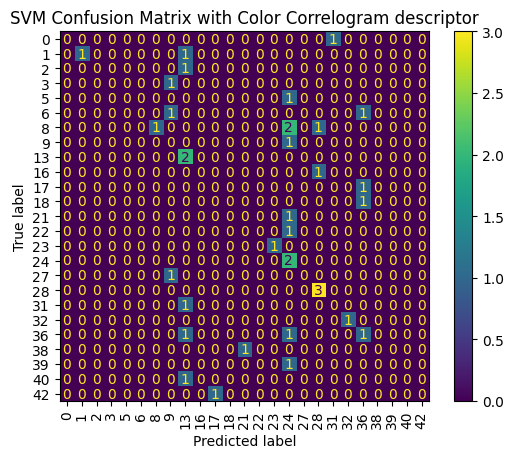

In [24]:
# Get confusion matrix for test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm_preds     = best_svm_classificator.predict(test_descriptors[best_svm_name])
knn_preds     = best_knn_classificator.predict(test_descriptors[best_knn_name])
xgboost_preds = best_xgboost_classificator.predict(test_descriptors[best_xgboost_name])

svm_labels     = sorted(set(test["class_id"].to_list()) | set(svm_preds.tolist()))
knn_labels     = sorted(set(test["class_id"].to_list()) | set(knn_preds.tolist()))
xgboost_labels = sorted(set(test_labels.tolist())       | set(xgboost_preds.tolist()))

svm_cm     = confusion_matrix(test["class_id"], svm_preds,     labels=svm_labels)
knn_cm     = confusion_matrix(test["class_id"], knn_preds,     labels=knn_labels)
xgboost_cm = confusion_matrix(test_labels,      xgboost_preds, labels=xgboost_labels)

disp = ConfusionMatrixDisplay(svm_cm, display_labels=svm_labels)
disp.plot(xticks_rotation=90)
plt.title(f"SVM Confusion Matrix with {best_svm_name} descriptor")
plt.show()

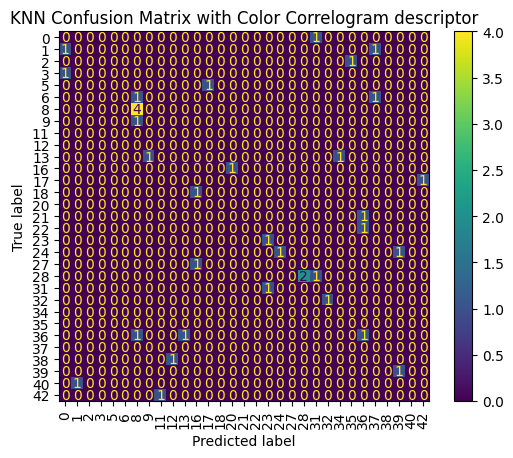

In [25]:
disp = ConfusionMatrixDisplay(knn_cm, display_labels=knn_labels)
disp.plot(xticks_rotation=90)
plt.title(f"KNN Confusion Matrix with {best_knn_name} descriptor")
plt.show()

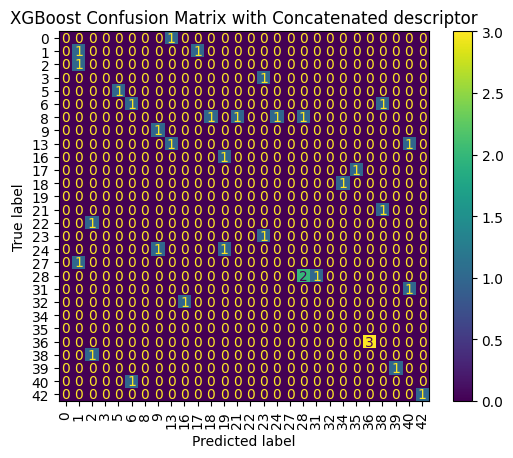

In [26]:
disp = ConfusionMatrixDisplay(xgboost_cm, display_labels=le.classes_[xgboost_labels])
disp.plot(xticks_rotation=90)
plt.title(f"XGBoost Confusion Matrix with {best_xgboost_name} descriptor")
plt.show()

# Search
Now I will implement search yielding images similar to the one I used using euclidean distance

In [43]:
all_df = pl.concat([train, test, val])

all_descriptors = {}
for name in train_descriptors.keys():
    all_descriptors[name] = np.concatenate([train_descriptors[name], test_descriptors[name], val_descriptors[name]])

def search_images(descriptor_name, query_image_path, top_k=5):
    query_descriptor = descriptors[descriptor_name](plt.imread(query_image_path))
    distances = np.linalg.norm(all_descriptors[descriptor_name] - query_descriptor, axis=1)
    nearest_indices = np.argsort(distances)[:top_k]
    return all_df[nearest_indices]

In [44]:
def search_and_plot(descriptor_name, query_image_path):
    imgs = search_images(descriptor_name, query_image_path, top_k=10)

    plt.figure(figsize=(15, 10))
    for i in range(len(imgs)):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(plt.imread("pets256/" + imgs[i]["filename"].item().strip()))
        plt.title(f"{imgs[i]['class_name'].item().strip()}\n(id: {imgs[i]['class_id'].item()})")
        plt.axis('off')

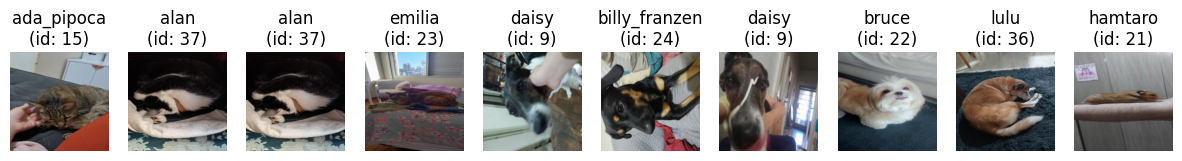

In [45]:
search_and_plot("Color Correlogram", "pets256/ada_pipoca/00127.jpg")

# It did not work :/
It found cats, and emilia is very similar to ada_pipoca, but the other images of ada pipoca arent there, and it found a lot of dogs :(

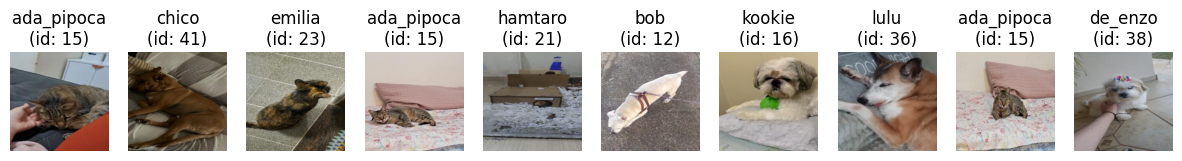

In [46]:
search_and_plot("GIST", "pets256/ada_pipoca/00127.jpg")

# HMM
With GIST it got more ada_pipocas there, but it still getting a lot of dogs

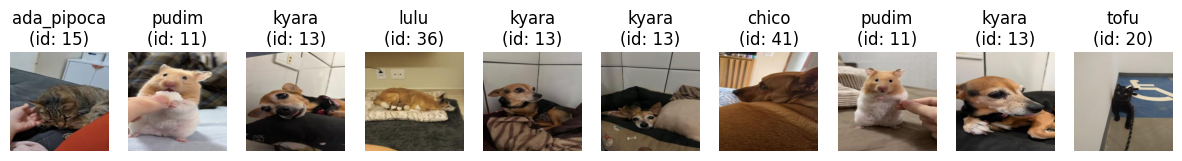

In [47]:
search_and_plot("Haralick", "pets256/ada_pipoca/00127.jpg")

# Haralick was kinda bad at ADA Pipoca

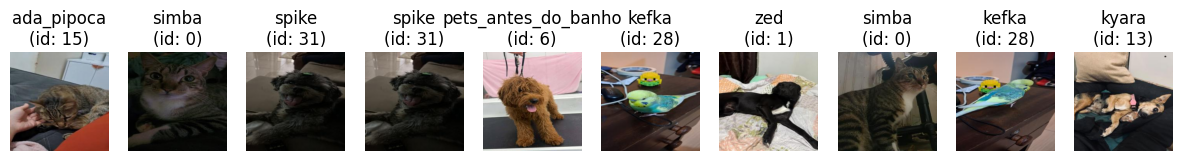

In [48]:
search_and_plot("Local Binary Patterns", "pets256/ada_pipoca/00127.jpg")

# LBP was very bad too, gist is winning still

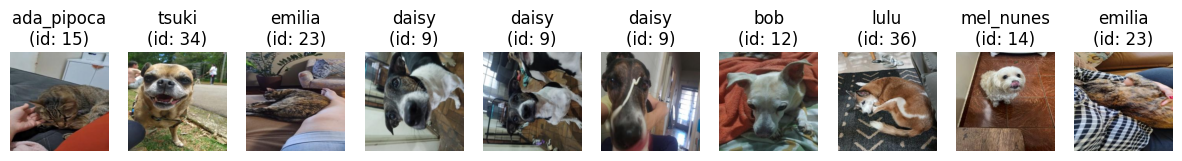

In [49]:
search_and_plot("Global Histogram", "pets256/ada_pipoca/00127.jpg")

# Histogram is kinda bad too, as this ADA Pipoca is very small in the image

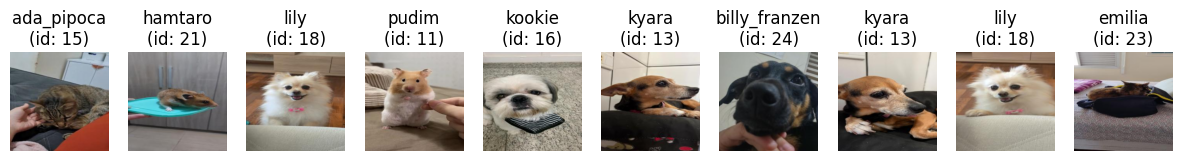

In [56]:
search_and_plot("Histogram of Oriented Gradients", "pets256/ada_pipoca/00127.jpg")

# Now I will try bag of visual Words

In [50]:
from sklearn.cluster import MiniBatchKMeans

def extract_patches(img, patch_size=8, step=16):
    img = luminosity(img).astype(float)
    H, W = img.shape
    patches = []
    for r in range(0, H - patch_size, step):
        for c in range(0, W - patch_size, step):
            patches.append(img[r:r+patch_size, c:c+patch_size].ravel())
    return np.array(patches)

def build_vocabulary(train_df, k=128, patch_size=8, step=16):
    all_patches = []
    for path in tqdm.tqdm(train_df["filename"], desc="Extracting patches"):
        img = plt.imread("pets256/" + path.strip())
        all_patches.append(extract_patches(img, patch_size, step))
    all_patches = np.vstack(all_patches)
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    kmeans.fit(all_patches)
    return kmeans

def bovw_descriptor(img, vocabulary, patch_size=8, step=16):
    patches = extract_patches(img, patch_size, step)
    assignments = vocabulary.predict(patches)
    k = vocabulary.n_clusters
    hist, _ = np.histogram(assignments, bins=np.arange(k + 1))
    return hist.astype(float) / hist.sum()


In [51]:
print("Building visual vocabulary (k=128)...")
vocabulary = build_vocabulary(train, k=128)
descriptors["BoVW"] = lambda img, vocab=vocabulary: bovw_descriptor(img, vocab)

print("Computing BoVW descriptors...")
train_bovw = np.array([bovw_descriptor(plt.imread("pets256/" + p.strip()), vocabulary) for p in tqdm.tqdm(train["filename"], desc="Train")])
val_bovw   = np.array([bovw_descriptor(plt.imread("pets256/" + p.strip()), vocabulary) for p in tqdm.tqdm(val["filename"],   desc="Val")])
test_bovw  = np.array([bovw_descriptor(plt.imread("pets256/" + p.strip()), vocabulary) for p in tqdm.tqdm(test["filename"],  desc="Test")])

train_descriptors["BoVW"] = train_bovw
val_descriptors["BoVW"]   = val_bovw
test_descriptors["BoVW"]  = test_bovw

print(f"BoVW descriptor shape: {train_bovw.shape}")


Building visual vocabulary (k=128)...


Extracting patches: 100%|██████████| 289/289 [00:00<00:00, 1238.66it/s]


Computing BoVW descriptors...


Test: 100%|██████████| 36/36 [00:00<00:00, 974.32it/s]

BoVW descriptor shape: (289, 128)


# BoVW Search

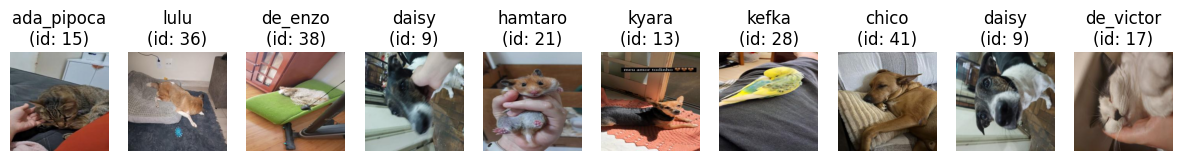

In [52]:
search_and_plot("BoVW", "pets256/ada_pipoca/00127.jpg")

# Arg it is bad too, Ada Pipoca is so hard

# BoVW Classification

In [53]:
svm_bovw = sklearn.svm.SVC(random_state=42)
svm_bovw.fit(train_bovw, train["class_id"])
print(f"BoVW SVM val accuracy:  {svm_bovw.score(val_bovw,  val['class_id']):.4f}")
print(f"BoVW SVM test accuracy: {svm_bovw.score(test_bovw, test['class_id']):.4f}")

knn_bovw = sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)
knn_bovw.fit(train_bovw, train["class_id"])
print(f"BoVW KNN val accuracy:  {knn_bovw.score(val_bovw,  val['class_id']):.4f}")
print(f"BoVW KNN test accuracy: {knn_bovw.score(test_bovw, test['class_id']):.4f}")

xgboost_bovw = xgboost.XGBClassifier(random_state=42, eval_metric='mlogloss')
xgboost_bovw.fit(train_bovw, train_labels)
print(f"BoVW XGBoost val accuracy:  {xgboost_bovw.score(val_bovw, val_labels):.4f}")
print(f"BoVW XGBoost test accuracy: {xgboost_bovw.score(test_bovw, test_labels):.4f}")

BoVW SVM val accuracy:  0.1892
BoVW SVM test accuracy: 0.1389
BoVW KNN val accuracy:  0.1081
BoVW KNN test accuracy: 0.1667
BoVW XGBoost val accuracy:  0.1892
BoVW XGBoost test accuracy: 0.1944


# It is also kinda bad on classification

# BoVW Projection: t-SNE and UMAP

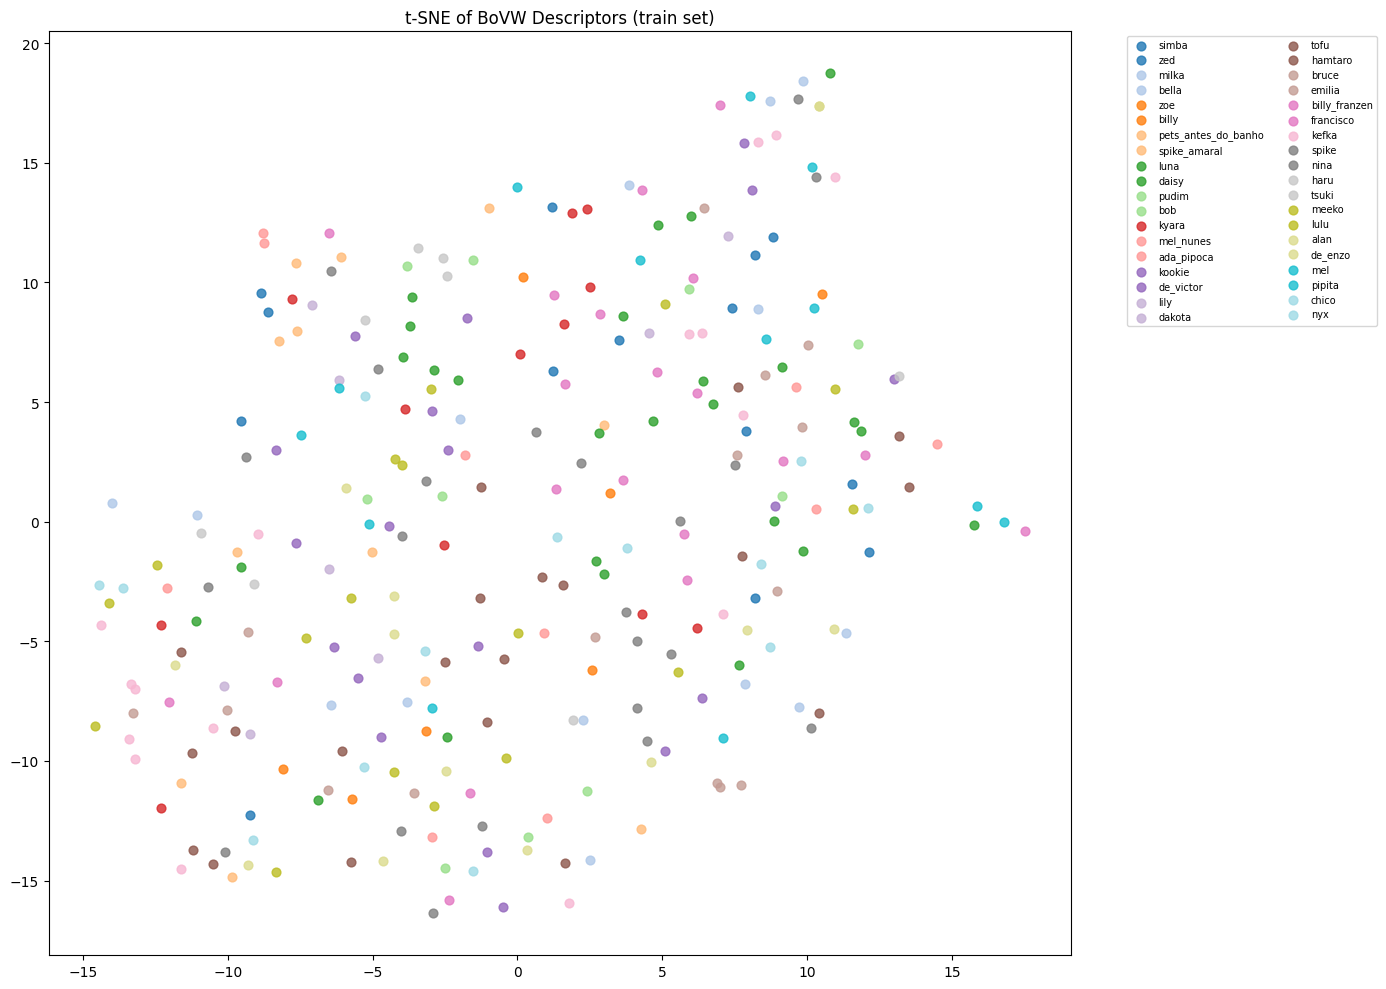

In [54]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(train_bovw)

class_ids = train["class_id"].to_numpy()
class_names = [name.strip() for name in train["class_name"].to_list()]
unique_ids = np.unique(class_ids)

plt.figure(figsize=(14, 10))
cmap = plt.get_cmap("tab20", len(unique_ids))
for i, cid in enumerate(unique_ids):
    mask = class_ids == cid
    label = class_names[np.where(mask)[0][0]]
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=cmap(i), label=label, s=40, alpha=0.8)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.title("t-SNE of BoVW Descriptors (train set)")
plt.tight_layout()
plt.show()


/home/clr/Repos/ImageProcessing/Trab3/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


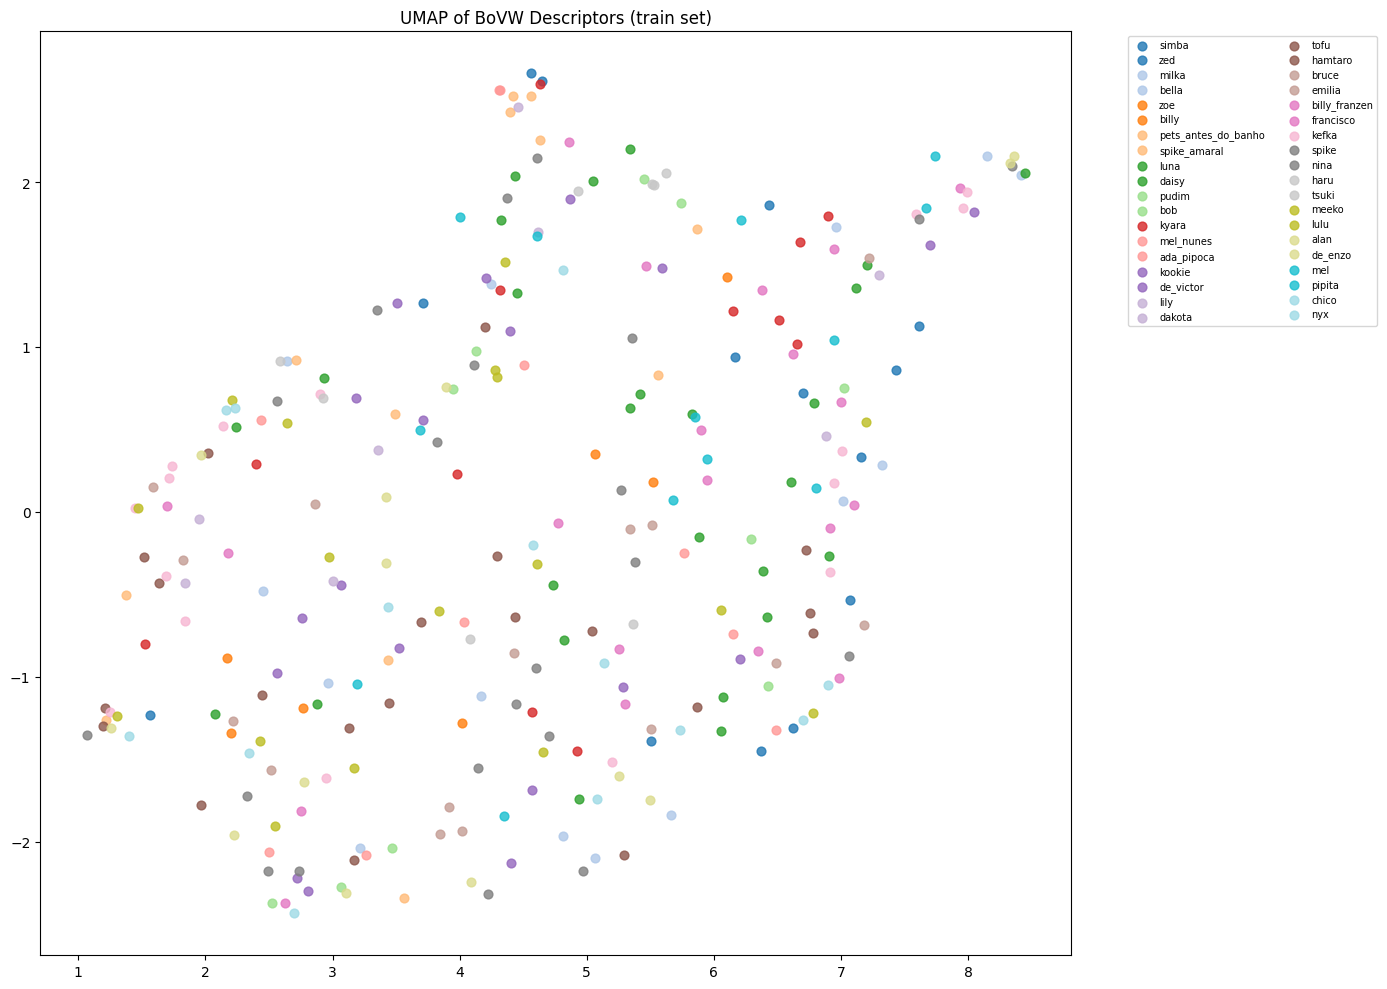

In [55]:
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(train_bovw)

plt.figure(figsize=(14, 10))
for i, cid in enumerate(unique_ids):
    mask = class_ids == cid
    label = class_names[np.where(mask)[0][0]]
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], color=cmap(i), label=label, s=40, alpha=0.8)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.title("UMAP of BoVW Descriptors (train set)")
plt.tight_layout()
plt.show()